Understanding random variables and probability distributions through simulation. Observe how Bernoulli,Binomial and Poisson distributions behave.

In [1]:
# Getting Python ready
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
import math
import textwrap
from scipy.special import comb
#%matplotlib widget

In [2]:
def aBernoulliExperiment(randomNumGen, bernoulliParam_p=0.5, numRepeatsOfExp = 1, numTrialsInAnExp = 1, profitLoss=[1,0]):
    
    repeatIndex = 0
    observation = np.ones((numRepeatsOfExp, numTrialsInAnExp))
    #print(observation)

    observation = randomNumGen.random((numRepeatsOfExp, numTrialsInAnExp))

    index_ge1 = np.less_equal(observation, bernoulliParam_p)
    
    observation[index_ge1] = profitLoss[0]
    observation[np.invert(index_ge1)] = profitLoss[1]
    return observation

The function takes random numbers between 0 and 1, and converts them into coin tosses.
When a number is generated, if it is below 0.2(value of p), then consider it has heads otherwise it is tails.

Question 1 (a) Coin is tossed $20$ times. We need to plot outcomes against the trial number

Each coin toss is a Bernoulli random variable with p=0.2 where 1=heads and 0=tails

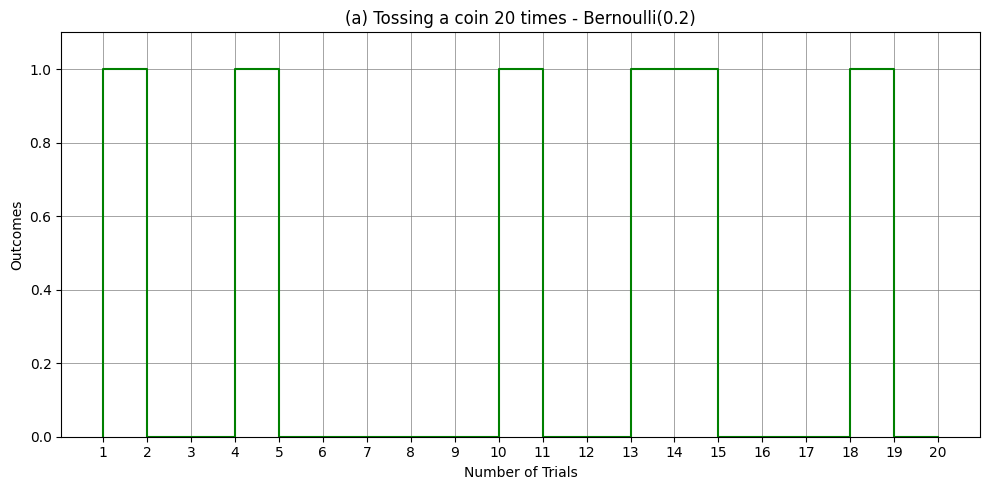

In [3]:
#Question 1 (a)

N=20 #no of coin tosses
p=0.2 #P[head]
rng=np.random.default_rng(1000)
obs=aBernoulliExperiment(rng, bernoulliParam_p=p, numRepeatsOfExp=1, numTrialsInAnExp=N)

tosses=rng.random(N)
tosses=(tosses <= p).astype(int) # heads=1, tails=0

#plotting
fig,axis=plt.subplots(figsize=(10, 5))
axis.step(range(1,N+1), tosses, where='pre', color='green')
axis.set_xlabel('Number of Trials')
axis.set_ylabel('Outcomes')
axis.set_title('(a) Tossing a coin 20 times - Bernoulli(0.2)')
axis.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axis.set_xticks(range(1, N+1))
axis.set_ylim(bottom=0, top=1.1)
plt.tight_layout()
axis.grid(True, which='both', linestyle='-', linewidth=0.5, color='gray')
axis.set_axisbelow(True)
plt.show()

Total number of trials are 20
rng - to generate a random number
obs - output of the Bernoulli function
tosses - 20 random numbers mapped to $0$ or $1$ based on p

Out of 20 tosses, heads appear in trials 1,2,4,5,10,11,13,14,15,18,19 - that is 11 trials out of 20 which is high for p=0.2. But this is just a random sequence and does not reflect the theoretical probability.

Law of small numbers: This shows that small sample sizes (n=20) do not always show the actual probbaility.

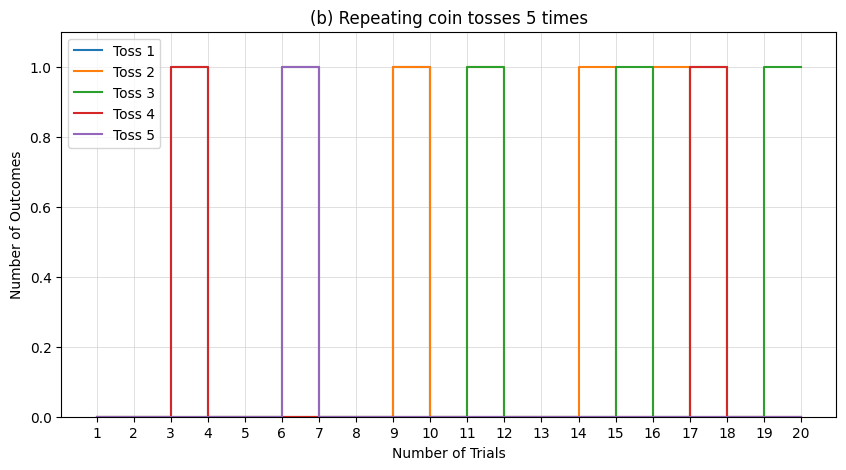

In [4]:
#Question 1 (b)

N=20
rng=np.random.default_rng(100)
repeat=5 #no. of times to repeat
p=0.2

fig, axis=plt.subplots(figsize=(10, 5))

for i in range(repeat):
    obs=aBernoulliExperiment(rng, bernoulliParam_p=p, numRepeatsOfExp=1, numTrialsInAnExp=N)
    axis.step(range(1, N+1), obs[0], where='pre', label=f'Toss {i+1}')

axis.set_xlabel('Number of Trials')
axis.set_ylabel('Number of Outcomes')
axis.set_title('(b) Repeating coin tosses 5 times')
axis.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axis.set_xticks(range(1, N+1))
axis.set_ylim(bottom=0, top=1.1)
axis.grid(True, which='both', linestyle='-', linewidth=0.5, color='lightgray')
axis.legend(loc='upper left')
plt.show()

Now we have 5 tosses repeated 20 times each. Even if each sequence has the same probability of p=0.2, the actual outcomes differ.Like, Toss 1 (blue) got no heads at all.

However, most of the trials are concentrated at 0 indicating that the failure probability (p=0.8) is higher.

This plot also shows that 'Toss 1' failing for all the trials had no effect on the other tosses. Hence, these are independent events.

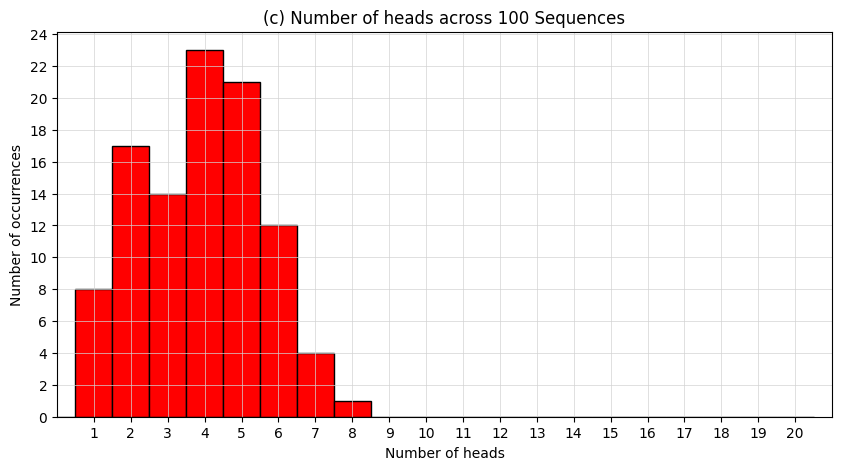

In [5]:
#Question 1(c)

N=20
rng = np.random.default_rng(500)
repeat=100
p=0.2

#100 sequences of 20 each
obs=aBernoulliExperiment(rng, bernoulliParam_p=p, numRepeatsOfExp=repeat, numTrialsInAnExp=N)
counth = np.sum(obs, axis=1)  #total heads per sequence

fig, axis=plt.subplots(figsize=(10, 5))
axis.hist(counth, bins=range(0, N+2), align='left', rwidth=1.0, edgecolor='black',color="red")
axis.set_xlabel('Number of heads')
axis.set_ylabel('Number of occurrences')
axis.set_title('(c) Number of heads across 100 Sequences')
axis.set_xticks(range(1, N+1))
axis.set_yticks(range(0, 26, 2))
axis.set_xlim(0, N+1)
axis.grid(True, linestyle='-', linewidth=0.5, color='lightgray')
plt.show()

Now we have 100 sequences and we observe that the histogram resembles the PMF of a Binomial (n=20,p=0.2) RV.
The histogram peaks around 4 and 5 heads.
This matches the expected value: E[X]= n x p = 20 x 0.2 = 4. 

Most sequences got between 2 and 6 heads, and very few got more than 8. No sequence got 0 or more than 8 heads out of 20 tosses.


Sequences with sum greater than or equal to 3: 75 out of 100


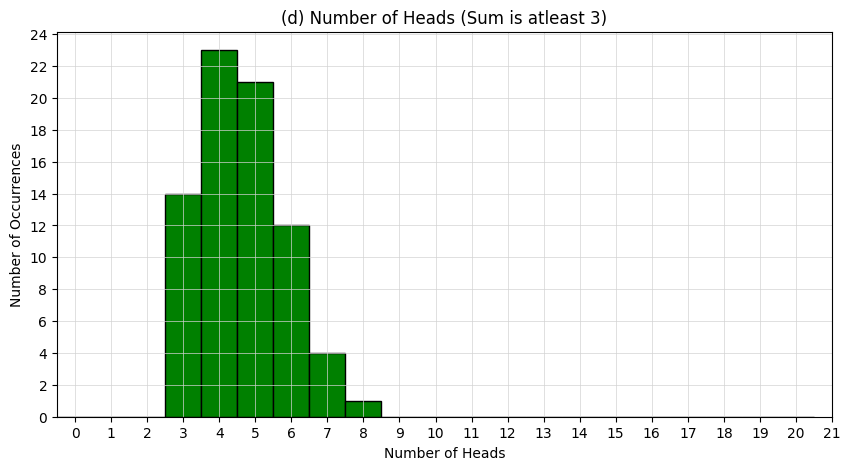

In [6]:
#Question 1 (d)
N=20
count=counth[counth>=3] #sequences with 3 or more heads
print(f"\nSequences with sum greater than or equal to 3: {len(count)} out of 100")

fig, axis=plt.subplots(figsize=(10, 5))
axis.hist(count, bins=range(0, N+2), align='left', rwidth=1.0, edgecolor='black', color='green')
axis.set_xlabel('Number of Heads')
axis.set_ylabel('Number of Occurrences')
axis.set_title('(d) Number of Heads (Sum is atleast 3)')
axis.set_xticks(range(0, N+2))
axis.set_xlim(-0.5, N+1)
axis.set_yticks(range(0, 26, 2))
axis.grid(True, linestyle='-', linewidth=0.5, color='lightgray')
plt.show()

The histogram now starts abruptly at x=3. The left part of the graph is cut off by imposing the condition that sum should be atleast 3.

Even if lower values are gone, the distribution of the remaining values follows the same pattern as part (c).

This approximates a truncated Binomial (20,0.2) PMF, conditioned on the sum being at least 3.

In parts (a) and (b), these parts show that a single sequence is highly unpredictable. It represents high variance in small samples and confirms that each experiment is independent.

In (c), it represents law of large numbers (as you increase the number of trials, the observed prababilty will get closer to the actual probability)

In (d), applying a condition moves our focus to a subset of the data. It illustrates how conditional probability works, by removing the failure-heavy outcomes, we shifter the average upwards.

In [7]:
#Question 2
rng=np.random.default_rng(150)
alphas=rng.uniform(0, 100, 4) #4 random alpha values
print("Alpha values:",np.round(alphas, 2))

Alpha values: [ 0.48 93.08 78.46 33.43]



α = 0.48
n = 1000, p = 0.0004822044056611019
Mean of Binomial ≈ 0.48, Variance ≈ 0.48
Mean of Poisson  ≈ 0.49, Variance ≈ 0.48

α = 93.08
n = 9307, p = 0.010000934970487322
Mean of Binomial ≈ 93.14, Variance ≈ 91.94
Mean of Poisson  ≈ 93.06, Variance ≈ 92.49

α = 78.46
n = 7845, p = 0.010001047941130938
Mean of Binomial ≈ 78.47, Variance ≈ 77.32
Mean of Poisson  ≈ 78.44, Variance ≈ 77.89

α = 33.43
n = 3343, p = 0.010000746613054782
Mean of Binomial ≈ 33.42, Variance ≈ 33.13
Mean of Poisson  ≈ 33.42, Variance ≈ 33.49


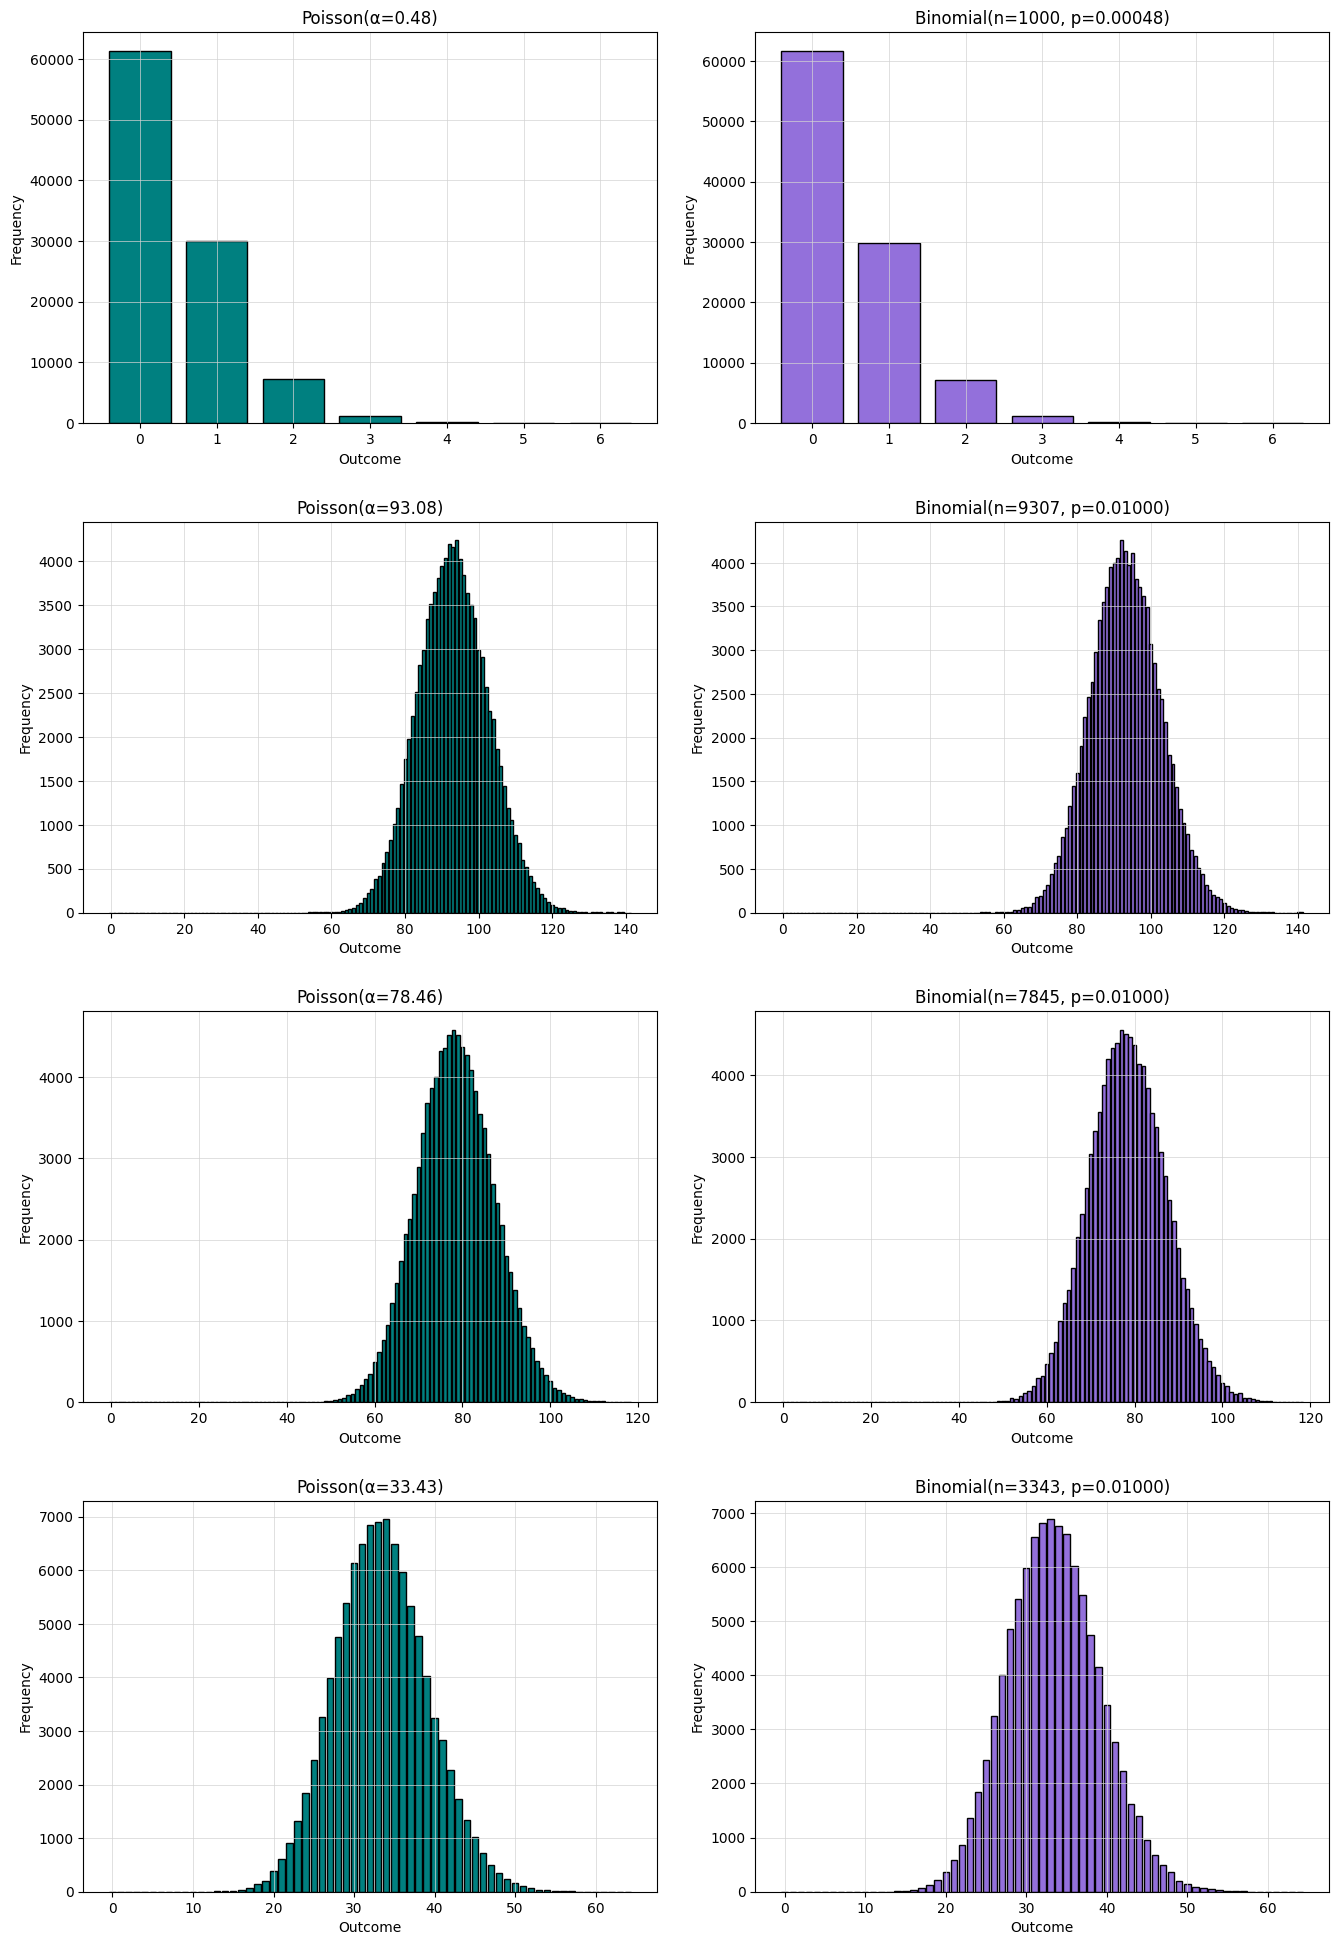

In [8]:
no=100000 #no. of simulations

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 20))
plt.tight_layout(pad=4.0, h_pad=5.0)

for i, alpha in enumerate(alphas):
    n=max(1000, int(alpha * 100)) #large n so Binomial=Poisson
    p=alpha/n

    poissonsamp=np.random.poisson(lam=alpha, size=no)
    binomialsamp=np.random.binomial(n=n, p=p, size=no)

    maxv = int(max(np.max(poissonsamp), np.max(binomialsamp))) + 2 #upper limit

    # Plot Poisson
    axes[i][0].hist(poissonsamp, bins=range(0, maxv), align='left', rwidth=0.8, edgecolor='black', color='teal')
    axes[i][0].set_title(f'Poisson(α={alpha:.2f})')
    axes[i][0].set_xlabel('Outcome')
    axes[i][0].set_ylabel('Frequency')
    axes[i][0].grid(True, linestyle='-', linewidth=0.5, color='lightgray')

    # Plot Binomial
    axes[i][1].hist(binomialsamp, bins=range(0, maxv), align='left', rwidth=0.8, edgecolor='black', color='mediumpurple')
    axes[i][1].set_title(f'Binomial(n={n}, p={p:.5f})')
    axes[i][1].set_xlabel('Outcome')
    axes[i][1].set_ylabel('Frequency')
    axes[i][1].grid(True, linestyle='-', linewidth=0.5, color='lightgray')

    print(f"\nα = {alpha:.2f}")
    print(f"n = {n}, p = {p}")
    print(f"Mean of Binomial ≈ {np.mean(binomialsamp):.2f}, Variance ≈ {np.var(binomialsamp):.2f}")
    print(f"Mean of Poisson  ≈ {np.mean(poissonsamp):.2f}, Variance ≈ {np.var(poissonsamp):.2f}")

plt.show()

For all the 4 values of α, the Poisson and Binomial histograms look almost identical. The means and variances printed also confirms this.
This confirms that as long as n is large and p is small, the Binomial distribution accurately approximates the Poisson.

For Binomial, variance=np(1-p). If p is very small, then 1-p will be very close 1, hence becomes close to the Poisson variance.
  
When α is small, suppose 0.48, both the distributions are on the right with most outcomes being 0 or 1. For larger α values (33, 78, 93), both distributions become bell-shaped and symmetric, centered around α.


======================= Alpha: α = 2.1537 =======================

  Sample Size = 1
  μ              = 2.1317
  σ              = 1.4566
  Min(data)      = 0
  Max(data)      = 10

  Sample Size = 10
  μ              = 21.5813
  σ              = 4.6429
  Min(data)      = 5
  Max(data)      = 40

  Sample Size = 100
  μ              = 215.3044
  σ              = 14.8605
  Min(data)      = 161
  Max(data)      = 272

  Sample Size = 1000
  μ              = 2154.6656
  σ              = 46.0477
  Min(data)      = 1978
  Max(data)      = 2353


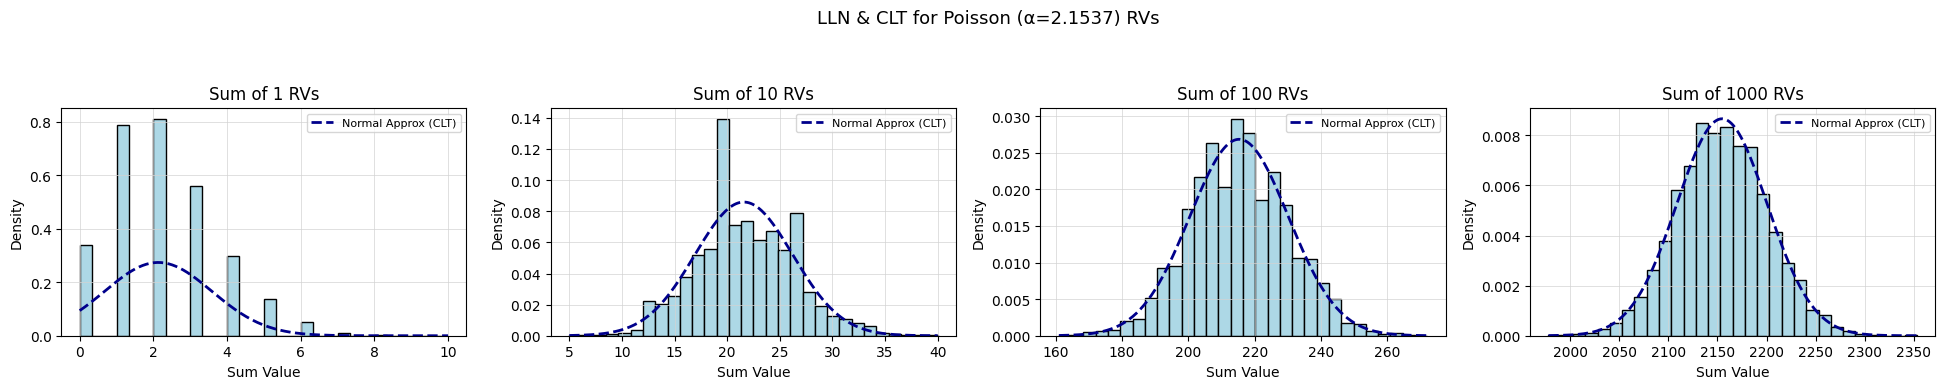


======================= Alpha: α = 10.5243 =======================

  Sample Size = 1
  μ              = 10.5496
  σ              = 3.2397
  Min(data)      = 0
  Max(data)      = 25

  Sample Size = 10
  μ              = 105.2268
  σ              = 10.2404
  Min(data)      = 64
  Max(data)      = 143

  Sample Size = 100
  μ              = 1052.7531
  σ              = 32.6926
  Min(data)      = 930
  Max(data)      = 1190

  Sample Size = 1000
  μ              = 10525.2123
  σ              = 102.5442
  Min(data)      = 10149
  Max(data)      = 10898


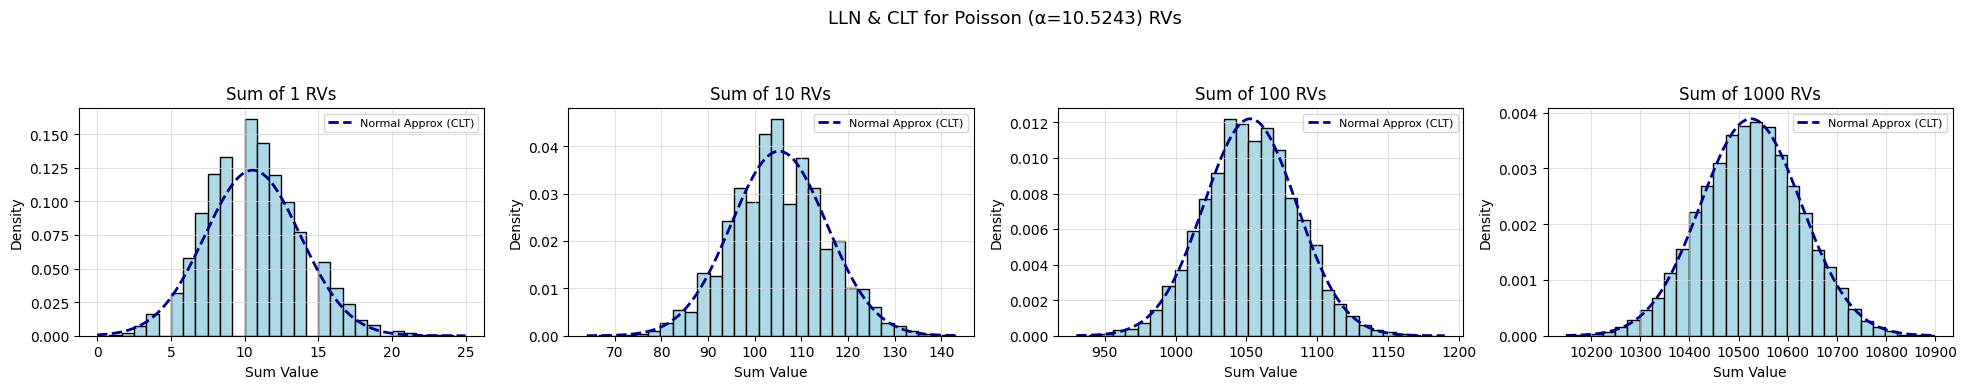

In [9]:
#Question 3

rng=np.random.default_rng(50)
alphas=np.array([2.1537, 10.5243])
samplesize = [1, 10, 100, 1000] #increasing number of RVs to sum
num= 10000 #repetitions per experiment

for alpha in alphas:
    print(f"\n{'='*23} Alpha: α = {alpha:.4f} {'='*23}")
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    plt.suptitle(f'LLN & CLT for Poisson (α={alpha}) RVs', fontsize=13)
    plt.tight_layout(pad=3.0)

    for j, k in enumerate(samplesize):
        samples = np.random.poisson(lam=alpha, size=(num, k)) #k RVs, num times
        sums = np.sum(samples, axis=1) #sum each row
        print(f"\n  Sample Size = {k}")
        print(f"  μ              = {np.mean(sums):.4f}")
        print(f"  σ              = {np.std(sums):.4f}")
        print(f"  Min(data)      = {np.min(sums)}")
        print(f"  Max(data)      = {np.max(sums)}")
        axes[j].hist(sums, bins=30, density=True, color='lightblue', edgecolor='black', rwidth=1.0)
        x = np.linspace(sums.min(), sums.max(), 200)
        axes[j].plot(x, norm.pdf(x, np.mean(sums), np.std(sums)), color='darkblue', linestyle='--', linewidth=2, label='Normal Approx (CLT)')
        axes[j].set_title(f'Sum of {k} RVs')
        axes[j].set_xlabel('Sum Value')
        axes[j].set_ylabel('Density')
        axes[j].legend(fontsize=8)
        axes[j].grid(True, linestyle='-', linewidth=0.5, color='lightgray')

    plt.show()  

LLN: As k increases, the histogram clusters tighter around the mean (k × α), and the relative variability decreases.

CLT: For small k (k=1), the histogram is skewed. As k increases to 100 and 1000, the skewness vanishes and becomes a Normal distribution. This is also seen as the dashed blue line fitting the histogram better.
This holds even though each individual Poisson RV is discrete and skewed.